In [1]:
import pandas as pd
import numpy as np 
import missingno as msno
import matplotlib.pyplot as plt
import re
import lightgbm as lgb

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error, median_absolute_error
)

from utils import load_dataset, persian_to_latin, extract_year, normalize_bool, to_jalali, parse_number, normalize_text

In [2]:
rent_df = load_dataset('Divar.csv')
rent_df.head()

c:\Users\Poori\Desktop\divar-estate-ml\src\utils.py:17: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
rent_df['is_tehran'] = (rent_df['city_slug'] == 'tehran').astype(int)

metropolis_cities = ['tehran', 'mashhad', 'isfahan', 'karaj', 'shiraz', 'tabriz', 'qom', 'ahvaz']
rent_df['is_metropolis'] = rent_df['city_slug'].isin(metropolis_cities).astype(int)
rent_df.head()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius,is_tehran,is_metropolis
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,...,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0,0,1
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0,1,1
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN,1,1
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1


<h3 dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir", 
align=right style="line-height:300%;font-family:vazir;color:#0099cc">
<font face="vazir" color="whitesmoke">
آماده‌سازی و فیلتر داده رهن و اجاره
</font>
</h3>


In [4]:
# فیلتر کردن رکوردهای رهن و اجاره بلندمدت
rent_df = rent_df[rent_df['cat2_slug'].isin(['residential-rent', 'commercial-rent'])].copy()
rent_df.shape

(353125, 62)

<h3 dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir", 
align=right style="line-height:300%;font-family:vazir;color:#0099cc">
<font face="vazir" color="whitesmoke">
تبدیل اعداد فارسی به لاتین</font>
</h3>
<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در دیتاست، ستون‌هایی مثل construction_year, building_size, land_size گاهی اعداد فارسی دارند.


</p>




In [5]:
# اعمال روی ستون‌های متنی که ممکن است عدد فارسی داشته باشند
text_cols = ['construction_year', 'land_size', 'building_size', 
             'rooms_count', 'floor', 'total_floors_count', 
             'unit_per_floor', 'title', 'description']

for col in text_cols:
    if col in rent_df.columns:
        rent_df[col] = rent_df[col].apply(persian_to_latin)

<h3 dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir", 
align=right style="line-height:300%;font-family:vazir;color:#0099cc">
<font face="vazir" color="whitesmoke">
استخراج سال ساخت
</font>
</h3>
<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
ستون construction_year مقادیر متنوعی دارد

</p>

In [6]:
rent_df['construction_year_clean'] = rent_df['construction_year'].apply(extract_year)

# محاسبه سن بنا بر اساس سال ۱۴۰۳
rent_df['building_age'] = 1403 - rent_df['construction_year_clean']
rent_df.loc[rent_df['building_age'] < 0, 'building_age'] = np.nan

<h3 dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir", 
align=right style="line-height:300%;font-family:vazir;color:#0099cc">
<font face="vazir" color="whitesmoke">
نرمال‌سازی ستون‌های has_*
</font>
</h3>
<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
مقادیر این ستون‌ها شامل True/False, true/false, unselect, خالی است.

</p>

In [7]:
bool_cols = [c for c in rent_df.columns if c.startswith('has_')]
bool_cols += ['is_rebuilt', 'rent_credit_transform']

for col in bool_cols:
    if col in rent_df.columns:
        rent_df[col] = rent_df[col].apply(normalize_bool)

# تبدیل به نوع boolean قابل null
for col in bool_cols:
    if col in rent_df.columns:
        rent_df[col] = rent_df[col].astype('boolean')

In [8]:
rent_df['rooms_count'].value_counts()

rooms_count
دو              155099
یک               90345
سه               50686
بدون اتاق        45558
چهار              6288
پنج یا بیشتر      4642
Name: count, dtype: int64

In [9]:
rent_df['created_at_month'] = pd.to_datetime(rent_df['created_at_month'], errors='coerce')

rent_df['jalali_date'] = rent_df['created_at_month'].apply(to_jalali)
rent_df['jalali_year'] = rent_df['jalali_date'].apply(lambda x: x.year if pd.notna(x) else np.nan)
rent_df['jalali_month'] = rent_df['jalali_date'].apply(lambda x: x.month if pd.notna(x) else np.nan)

# یک ستون ماه شمسی خوانا برای نمودار
month_names = ['فروردین','اردیبهشت','خرداد','تیر','مرداد','شهریور',
               'مهر','آبان','آذر','دی','بهمن','اسفند']

rent_df['jalali_month_name'] = rent_df['jalali_month'].apply(
    lambda x: month_names[int(x)-1] if pd.notna(x) and 1 <= int(x) <= 12 else np.nan
)

In [10]:
# دیکشنری تبدیل
rooms_map = {'بدون اتاق': 0,
             'یک': 1,
             'دو': 2,
             'سه': 3,
             'چهار': 4,
             'پنج یا بیشتر': 5}

# اعمال تبدیل
rent_df['rooms_count_clean'] = rent_df['rooms_count'].map(rooms_map)

# بررسی نتیجه
print(rent_df['rooms_count_clean'].value_counts(dropna=False).sort_index())

rooms_count_clean
0.0     45558
1.0     90345
2.0    155099
3.0     50686
4.0      6288
5.0      4642
NaN       507
Name: count, dtype: int64


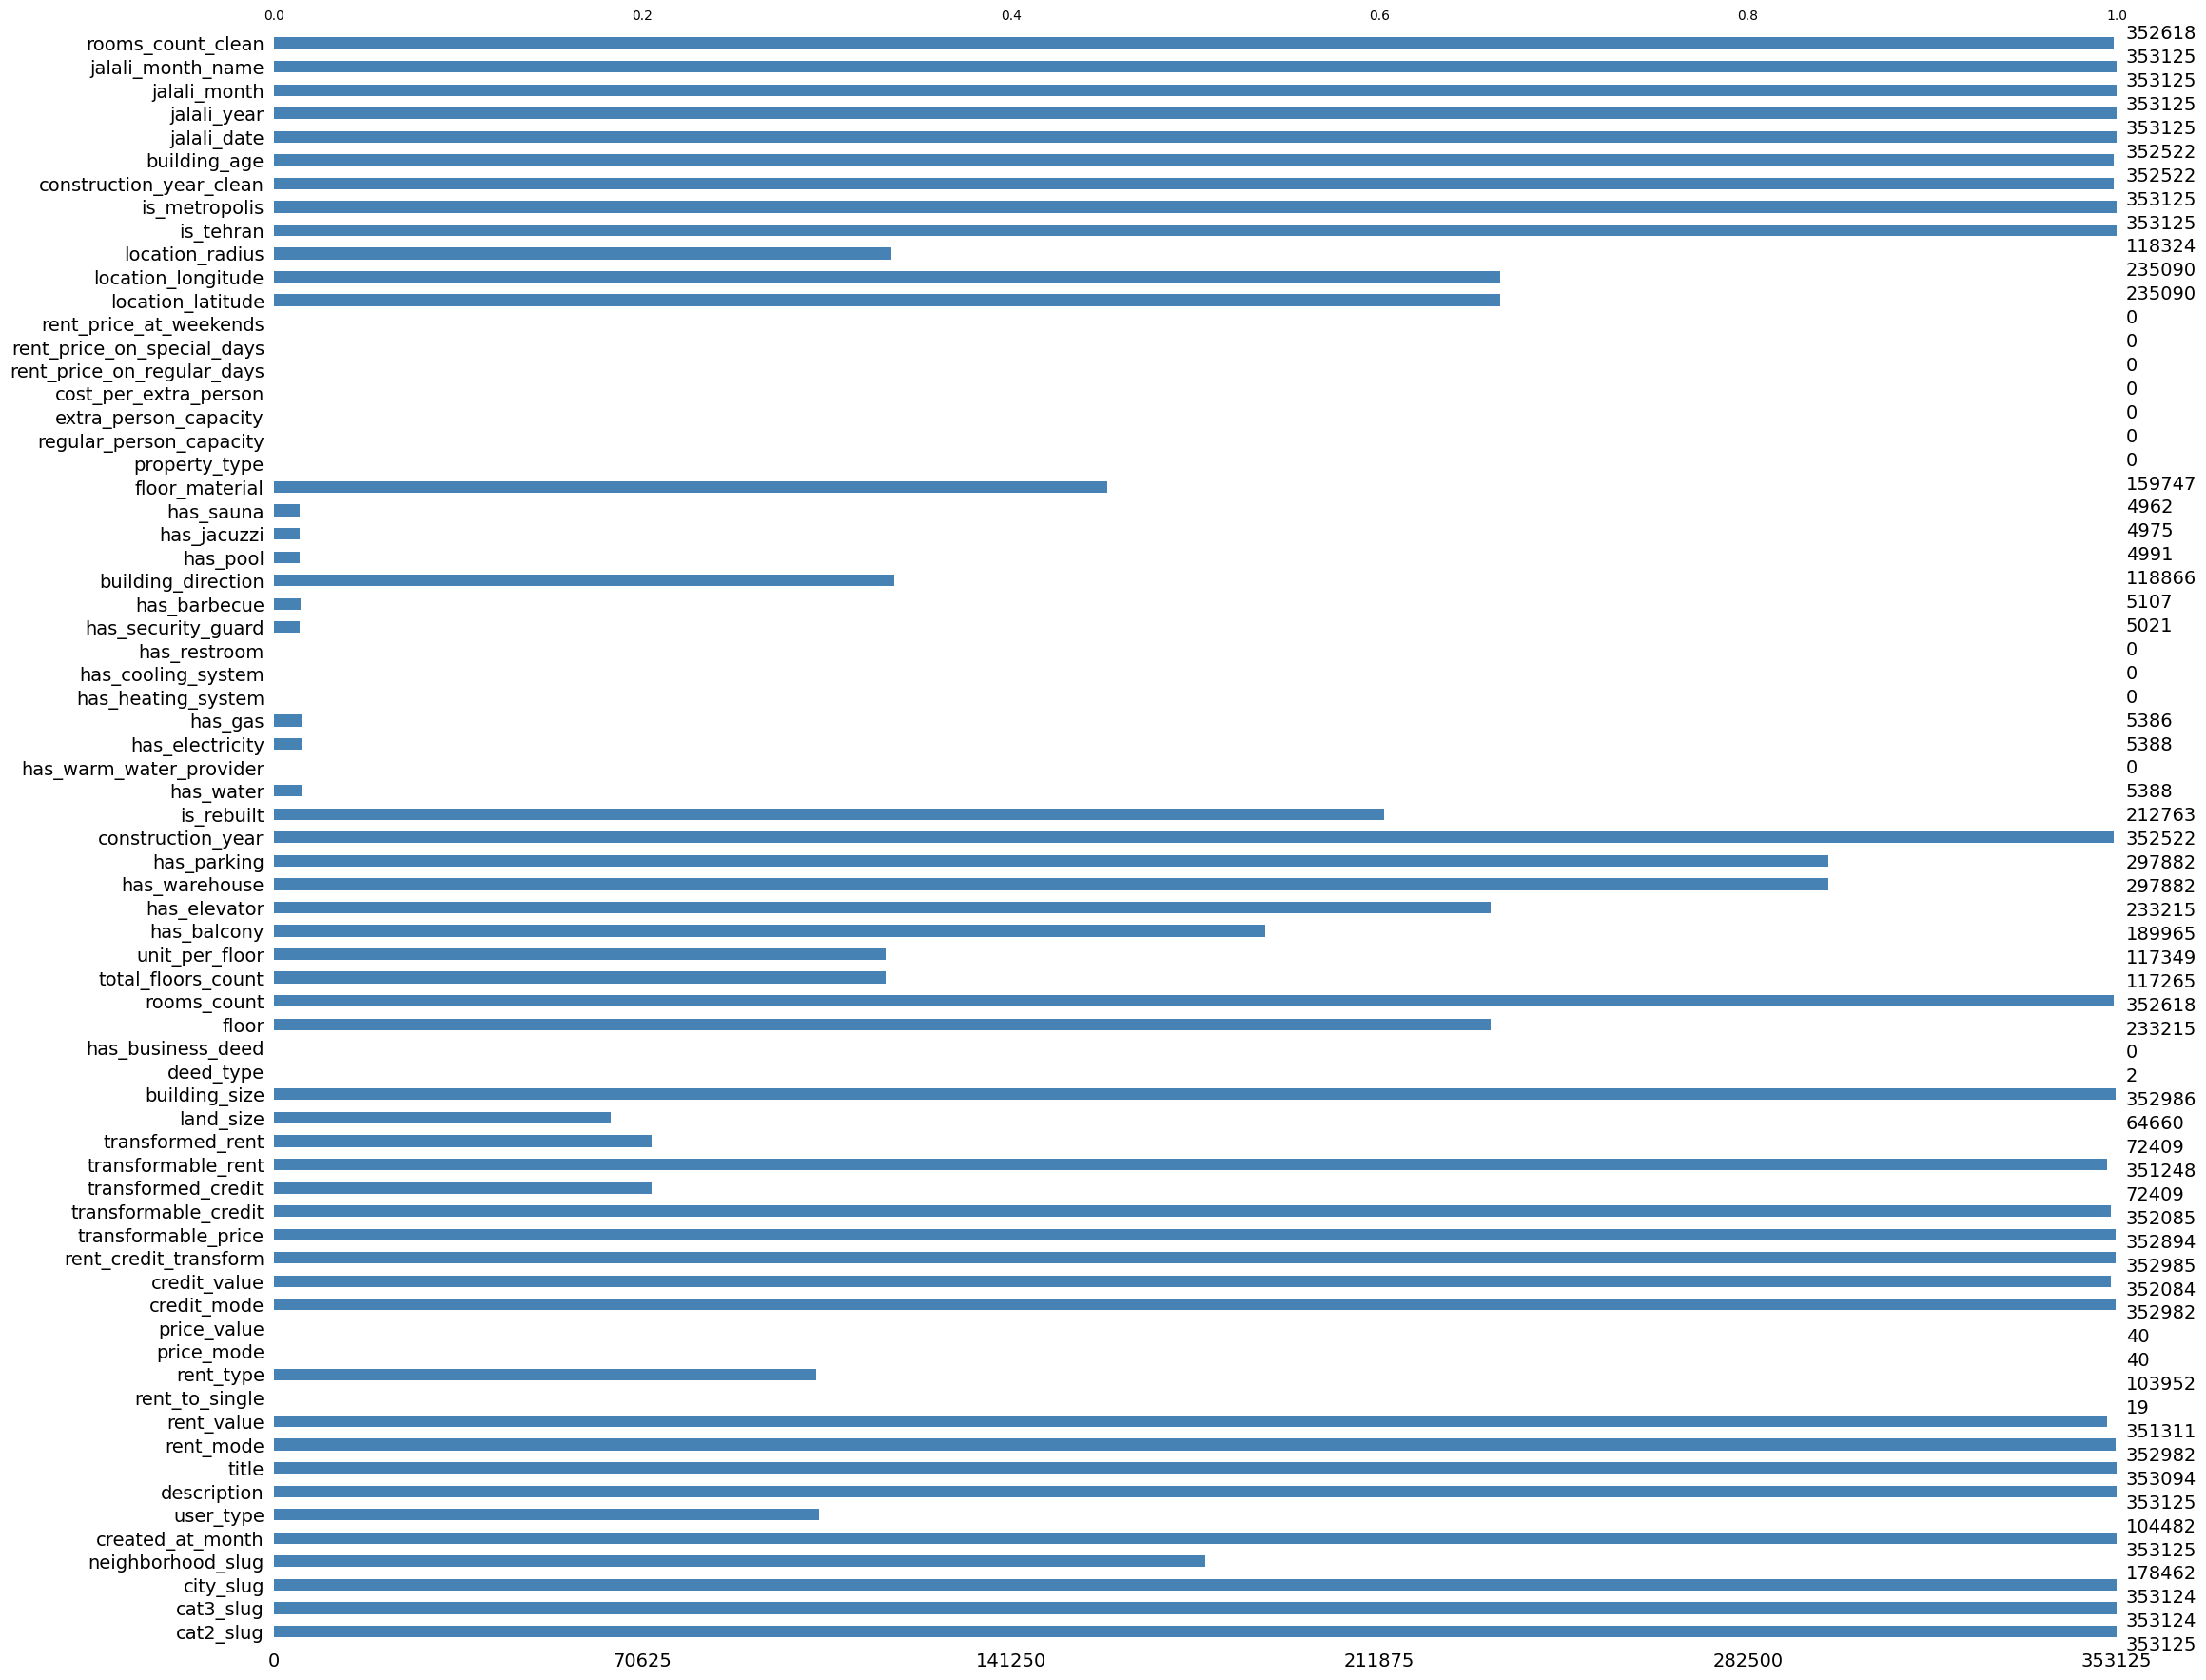

In [11]:
plt.figure(figsize=(18, 16))
msno.bar(rent_df, fontsize=14, color='steelblue')
plt.show()

In [12]:
# بررسی توزیع هدف
target_col = 'transformed_credit'

# تبدیل به عدد
rent_df[target_col] = pd.to_numeric(rent_df[target_col], errors='coerce')

# مقادیر معتبر: بزرگ‌تر از صفر
rent_df = rent_df[rent_df[target_col] > 0].copy()

# حذف Outlier با IQR
Q1 = rent_df[target_col].quantile(0.01)
Q3 = rent_df[target_col].quantile(0.99)
rent_df = rent_df[
    (rent_df[target_col] >= Q1) & (rent_df[target_col] <= Q3)
].copy()
print(rent_df[target_col].describe())

count    7.105700e+04
mean     7.373251e+08
std      9.554618e+08
min      5.000000e+07
25%      2.100000e+08
50%      4.000000e+08
75%      8.200000e+08
max      8.000000e+09
Name: transformed_credit, dtype: float64


In [13]:
numeric_raw_cols = ['floor', 'total_floors_count', 'unit_per_floor',
                    'land_size', 'building_size']

for col in numeric_raw_cols:
    rent_df[col + '_clean'] = rent_df[col].apply(parse_number)

In [14]:
has_cols = [col for col in rent_df.columns if col.startswith('has_')]
nan_before = rent_df[has_cols].isna().sum()
nan_before

has_business_deed          71057
has_balcony                25490
has_elevator               13766
has_warehouse               4614
has_parking                 4614
has_water                  70164
has_warm_water_provider    71057
has_electricity            70162
has_gas                    70162
has_heating_system         71057
has_cooling_system         71057
has_restroom               71057
has_security_guard         70261
has_barbecue               70236
has_pool                   70266
has_jacuzzi                70276
has_sauna                  70278
dtype: int64

In [15]:
# دیکشنری کلیدواژه‌ها برای هر ستون
amenity_keywords = {
    'has_elevator': ['آسانسور', 'اسانسور', 'پله برقی'],
    'has_parking': ['پارکینگ', 'پاركينگ', 'پارکینگ'],
    'has_balcony': ['بالکن', 'بالكون', 'تراس', 'ایوان'],
    'has_warehouse': ['انباری', 'انبار'],
    'has_pool': ['استخر', 'pool'],
    'has_business_deed': ['سند تجاری', 'سند اداری', 'تجاری'],
    'has_water': ['آب', 'چاه آب', 'آب لوله'],
    'has_electricity': ['برق', 'الکتریسیته'],
    'has_gas': ['گاز', 'گاز شهری'],
    'has_warm_water_provider': ['آب گرم', 'پکیج', 'موتورخانه', 'آبگرمکن'],
}

# نرمال‌سازی ستون title
rent_df['title_desc_norm'] = rent_df['title'].apply(normalize_text) + ' ' + rent_df['description'].apply(normalize_text)

# پر کردن NaNها بر اساس کلیدواژه‌ها
for col, keywords in amenity_keywords.items():
    if col not in rent_df.columns:
        continue
    pattern = '|'.join(map(re.escape, keywords))
    mask = rent_df[col].isna() & rent_df['title_desc_norm'].str.contains(pattern, case=False, na=False)
    rent_df.loc[mask, col] = True


# حذف ستون موقت
rent_df.drop(columns=['title_desc_norm'], inplace=True)


In [16]:
nan_after = rent_df[has_cols].isna().sum()

# ساخت جدول مقایسه
report = pd.DataFrame({
    'تعداد NaN اولیه': nan_before,
    'تعداد NaN باقی‌مانده': nan_after,
    'تعداد پر شده': nan_before - nan_after,
    'درصد پر شدن': ((nan_before - nan_after) / nan_before * 100).round(2).fillna(0)
})

# مرتب‌سازی بر اساس بیشترین تعداد پر شده
report = report.sort_values('تعداد پر شده', ascending=False)

print(report)

                         تعداد NaN اولیه  تعداد NaN باقی‌مانده  تعداد پر شده  \
has_gas                            70162                 56597         13565   
has_water                          70164                 57946         12218   
has_warm_water_provider            71057                 64139          6918   
has_electricity                    70162                 64534          5628   
has_balcony                        25490                 19869          5621   
has_business_deed                  71057                 67658          3399   
has_pool                           70266                 68142          2124   
has_warehouse                       4614                  3976           638   
has_elevator                       13766                 13502           264   
has_parking                         4614                  4442           172   
has_heating_system                 71057                 71057             0   
has_restroom                       71057

<h3 dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir", 
align=right style="line-height:300%;font-family:vazir;color:#0099cc">
<font face="vazir" color="whitesmoke">
استفاده از گروه‌بندی بر اساس cat3_slug
</font>
</h3>
<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
برخی امکانات در نوع ملک خاصی رایج‌تر هستند. مثلاً:
has_elevator در apartment-sell و apartment-rent تقریباً همیشه True است.<br>
has_pool در villa و temporary-rent بیشتر است.<br>
has_warehouse در آپارتمان‌ها رایج است.<br>
برای هر ستون has_*، میانگین (درصد True) را به تفکیک cat3_slug حساب کن. اگر در یک گروه بیش از ۹۰٪ مقادیر True بود، NaNهای آن گروه را True بگذار. اگر کمتر از ۵٪ True بود، False بگذار. در غیر این صورت دست نزن.
</p>

In [17]:
for col in has_cols:
    if rent_df[col].isna().sum() == 0:
        continue
    # میانگین به تفکیک cat3_slug
    group_ratio = rent_df.groupby('cat3_slug')[col].mean()
    
    for cat, ratio in group_ratio.items():
        if pd.isna(ratio):
            continue
        mask = rent_df[col].isna() & (rent_df['cat3_slug'] == cat)
        if ratio >= 0.90:
            rent_df.loc[mask, col] = True
        elif ratio <= 0.05:
            rent_df.loc[mask, col] = False

<h3 dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir", 
align=right style="line-height:300%;font-family:vazir;color:#0099cc">
<font face="vazir" color="whitesmoke">
قوانین دامنه‌ای (Domain Rules)
</font>
</h3>
<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
has_water, has_electricity, has_gas: در شهرهای بزرگ تقریباً همیشه True هستند. اگر city_slug در لیست کلان‌شهرها باشد، NaN را True بگذار.<br>
has_elevator: اگر floor > 0 و cat3_slug شامل apartment باشد، احتمالاً True است. (البته استثنا هم دارد، اما به‌عنوان یک حدس اولیه خوب است.)<br>
has_parking: در آپارتمان‌های نوساز (سال ساخت > ۱۳۹۰) تقریباً همیشه True است.<br>
has_pool, has_jacuzzi, has_sauna: این‌ها امکانات لوکس و نادر هستند. اگر در متن ذکر نشده باشد، احتمالاً وجود ندارد. پس NaN را False بگذار. (این یک فرض است، اما در عمل جواب می‌دهد.)
</p>

In [18]:
# مثال: پر کردن آب، برق، گاز برای کلان‌شهرها
metropolis_cities = ['tehran','mashhad','isfahan','karaj','shiraz','tabriz','qom','ahvaz']
for col in ['has_water', 'has_electricity', 'has_gas']:
    if col in rent_df.columns:
        mask = rent_df[col].isna() & rent_df['city_slug'].isin(metropolis_cities)
        rent_df.loc[mask, col] = True

# مثال: پر کردن استخر، جکوزی، سونا با False (چون لوکس و نادرند)
for col in ['has_pool', 'has_jacuzzi', 'has_sauna']:
    if col in rent_df.columns:
        rent_df[col] = rent_df[col].fillna(False)

<h3 dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir", 
align=right style="line-height:300%;font-family:vazir;color:#0099cc">
<font face="vazir" color="whitesmoke">
 استخراج ویژگی «بالاشهر بودن» از ستون neighborhood_slug
</font>
</h3>
<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
برای اینکه مدل بتواند قدرت خرید و سطح رفاه یک محله را درک کند، باید محله‌های بالاشهر (اعیان‌نشین) را از سایر محله‌ها تفکیک کنیم. این کار به‌ویژه در کلان‌شهرها که شکاف قیمتی شدیدی بین محله‌های شمالی و جنوبی وجود دارد، اهمیت بالایی دارد.
</p>

In [19]:
# تعریف لیست محله‌های بالاشهر برای هر شهر
upscale_neighborhoods = {
    'tehran': [
        'zaferanieh', 'elahiyeh', 'niavaran', 'farmanieh', 'velenjak',
        'qeytariyeh', 'tajrish', 'kamranieh', 'saadatabad', 'shahrak_gharb',
        'jordan', 'mirdamad', 'pasdaran', 'ekhtiyarieh', 'qolhak',
        'darvus', 'mahmoudieh', 'aghdasiyeh', 'azgol', 'fereshteh',
        'jamaran', 'sahebqaranieh', 'suhanak', 'darabad', 'minicity',
        'chizar', 'dezashib', 'kashanak', 'bagh_ferdows'
    ],
    'isfahan': [
        'mardavij', 'jolfa', 'moshtaq', 'chaharbagh_bala', 'abbasabad',
        'sheikh_saduq', 'hezarjarib'
    ],
    'shiraz': [
        'maaliabad', 'farhangshahr', 'ghodousi_gharbi', 'qasrdasht',
        'afifabad', 'shahrak_beheshti'
    ],
    'mashhad': [
        'ahmadabad', 'sajjad', 'malekabad', 'vakilabad', 'hashemieh',
        'elahiyeh', 'haft_tir', 'kohsangi', 'faramarz_abbasi', 'honarستان',
        'kowsar', 'mollasadra', 'kolahdooz', 'sajjadshahr', 'hakim_nizami',
        'beheshti', 'seyed_razi', 'bahonar', 'farhad', 'nastaran'
    ]
}

# تابعی برای بررسی بالاشهر بودن یک محله
def is_upscale(city, neighborhood):
    if pd.isna(city) or pd.isna(neighborhood):
        return False
    # نرمال‌سازی: حروف کوچک، تبدیل فاصله و خط تیره به آندرلاین
    neighborhood_clean = str(neighborhood).lower().replace(' ', '_').replace('-', '_')
    city_clean = str(city).lower()
    return neighborhood_clean in upscale_neighborhoods.get(city_clean, [])

# اعمال تابع روی دیتافریم
rent_df['is_upscale_neighborhood'] = rent_df.apply(
    lambda row: is_upscale(row['city_slug'], row['neighborhood_slug']), axis=1).astype(int)

# ساخت ستون اختصاصی برای بالاشهرهای تهران
rent_df['is_tehran_upscale'] = ((rent_df['city_slug'] == 'tehran') & (rent_df['is_upscale_neighborhood'] == 1)).astype(int)

# ساخت ستون اختصاصی برای بالاشهرهای مشهد
rent_df['is_mashhad_upscale'] = ((rent_df['city_slug'] == 'mashhad') & (rent_df['is_upscale_neighborhood'] == 1)).astype(int)


<h3 dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir", 
align=right style="line-height:300%;font-family:vazir;color:#0099cc">
<font face="vazir" color="whitesmoke">
ساخت  ویژگی «میزان لوکس بودن» یک ملک
</font>
</h3>
<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
۱. لوکس مدرن (modern_luxury_score): امکاناتی که در ساختمان‌های نوساز و باکیفیت رایج هستند و به‌تنهایی نشان‌دهنده‌ی سطح بالای رفاه هستند، اما جزء امکانات نادر محسوب نمی‌شوند.<br>
has_elevator (آسانسور)<br>
has_parking (پارکینگ)<br>
has_warehouse (انباری)<br>
has_balcony (بالکن)<br>
has_barbecue (باربیکیو)<br><br>
۲. لوکس واقعی (true_luxury_score): امکاناتی که نادر، گران‌قیمت و مخصوص املاک فوق‌لوکس هستند و به‌تنهایی ارزش ملک را به‌شدت افزایش می‌دهند.<br>
has_pool (استخر)<br>
has_jacuzzi (جکوزی)<br>
has_sauna (سونا)<br>
has_security_guard (نگهبان/سکیوریتی)
</p>

In [20]:
# تعریف جداگانه‌ی لیست ستون‌ها
modern_luxury_cols = ['has_elevator', 'has_parking', 'has_warehouse', 'has_balcony', 'has_barbecue']
true_luxury_cols = ['has_pool', 'has_jacuzzi', 'has_sauna', 'has_security_guard']

# ساخت ستون امتیاز لوکس مدرن
available_modern = [c for c in modern_luxury_cols if c in rent_df.columns]
available_true = [c for c in true_luxury_cols if c in rent_df.columns]

rent_df['modern_luxury_score'] = rent_df[available_modern].fillna(False).sum(axis=1)
rent_df['true_luxury_score']   = rent_df[available_true].fillna(False).sum(axis=1)

# 3. ساخت یک ستون ترکیبی که کل لوکس بودن را نشان دهد
rent_df['total_luxury_score'] = (rent_df['modern_luxury_score'] + (rent_df['true_luxury_score'] * 2))

In [21]:
# لیست ستون‌های ۱۰۰٪ خالی
zero_cols = [
    'rent_price_at_weekends', 'rent_price_on_special_days', 'rent_price_on_regular_days',
    'cost_per_extra_person', 'extra_person_capacity', 'regular_person_capacity',
    'property_type', 'has_restroom', 'has_cooling_system', 'has_heating_system',
    'deed_type', 'credit_mode', 'price_value', 'price_mode', 'rent_type',
    'rent_to_single', 'rent_mode'
]

# حذف ستون‌ها از دیتافریم
rent_df.drop(columns=zero_cols, inplace=True, errors='ignore')

In [22]:
duplicate_cols = ['land_size', 'building_size', 'floor', 'rooms_count', 'total_floors_count', 'unit_per_floor']
rent_df.drop(columns=duplicate_cols, inplace=True, errors='ignore')

worthless_cols = ['location_radius', 'floor_material', 'title', 'description', 'created_at_month', 'location_latitude', 'location_longitude', ]
rent_df.drop(columns=worthless_cols, inplace=True, errors='ignore')

In [23]:
# تعریف ضریب تبدیل (هر ۱ میلیون رهن = ۳۰ هزار اجاره => ۳۳.۳۳)
CONVERSION_RATIO = 33.33

# ۳. محاسبه معادل رهن (Target)
# تبدیل اجاره به رهن و جمع با ودیعه (رهن)
rent_df['transformable_price'] = (
    rent_df['credit_value'] + (rent_df['rent_value'] * CONVERSION_RATIO)
)

# حذف رکوردهایی که هدفشان صفر است (چون منطقی نیستند)
rent_df = rent_df[rent_df['transformable_price'] > 0]

# بررسی نتایج
print("تعداد رکوردهای نهایی:", len(rent_df))
print("\nآمار توصیفی transformable_price:")
print(rent_df['transformable_price'].describe())

تعداد رکوردهای نهایی: 71057

آمار توصیفی transformable_price:
count    7.105700e+04
mean     1.235550e+09
std      1.803320e+09
min      5.999600e+07
25%      4.033330e+08
50%      7.000000e+08
75%      1.333250e+09
max      4.500000e+10
Name: transformable_price, dtype: float64


In [24]:
# ۱. تعریف لیست ستون‌های نشت‌دهنده (Data Leakage)
leakage_cols = ['rent_value', 'credit_value', 'rent_credit_transform', 'transformable_credit',
                'transformed_credit','transformable_rent', 'transformed_rent']

# ۲. تعریف لیست ستون‌های تکراری و بی‌معنی
useless_cols = ['cat2_slug', 'jalali_date', 'construction_year', 
                'building_direction', 'floor_material', 'jalali_month_name']

# ۳. نکته مهم: city_slug و neighborhood_slug و cat3_slug دیگر حذف نمی‌شوند.
# LightGBM می‌تواند categorical featureهای با cardinality نسبتاً بالا را مستقیماً مدیریت کند.
# حذف این متغیرها اطلاعات مکانی مهمی را از مدل می‌گرفت.

# ۴. حذف ستون‌های leakage و غیرضروری
rent_df.drop(columns=leakage_cols + useless_cols, inplace=True, errors='ignore')

print(f"تعداد ستون‌های باقی‌مانده: {rent_df.shape[1]}")
print("لیست ستون‌های نهایی:")
print(rent_df.columns.tolist())


تعداد ستون‌های باقی‌مانده: 38
لیست ستون‌های نهایی:
['cat3_slug', 'city_slug', 'neighborhood_slug', 'user_type', 'transformable_price', 'has_business_deed', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'is_rebuilt', 'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas', 'has_security_guard', 'has_barbecue', 'has_pool', 'has_jacuzzi', 'has_sauna', 'is_tehran', 'is_metropolis', 'construction_year_clean', 'building_age', 'jalali_year', 'jalali_month', 'rooms_count_clean', 'floor_clean', 'total_floors_count_clean', 'unit_per_floor_clean', 'land_size_clean', 'building_size_clean', 'is_upscale_neighborhood', 'is_tehran_upscale', 'is_mashhad_upscale', 'modern_luxury_score', 'true_luxury_score', 'total_luxury_score']


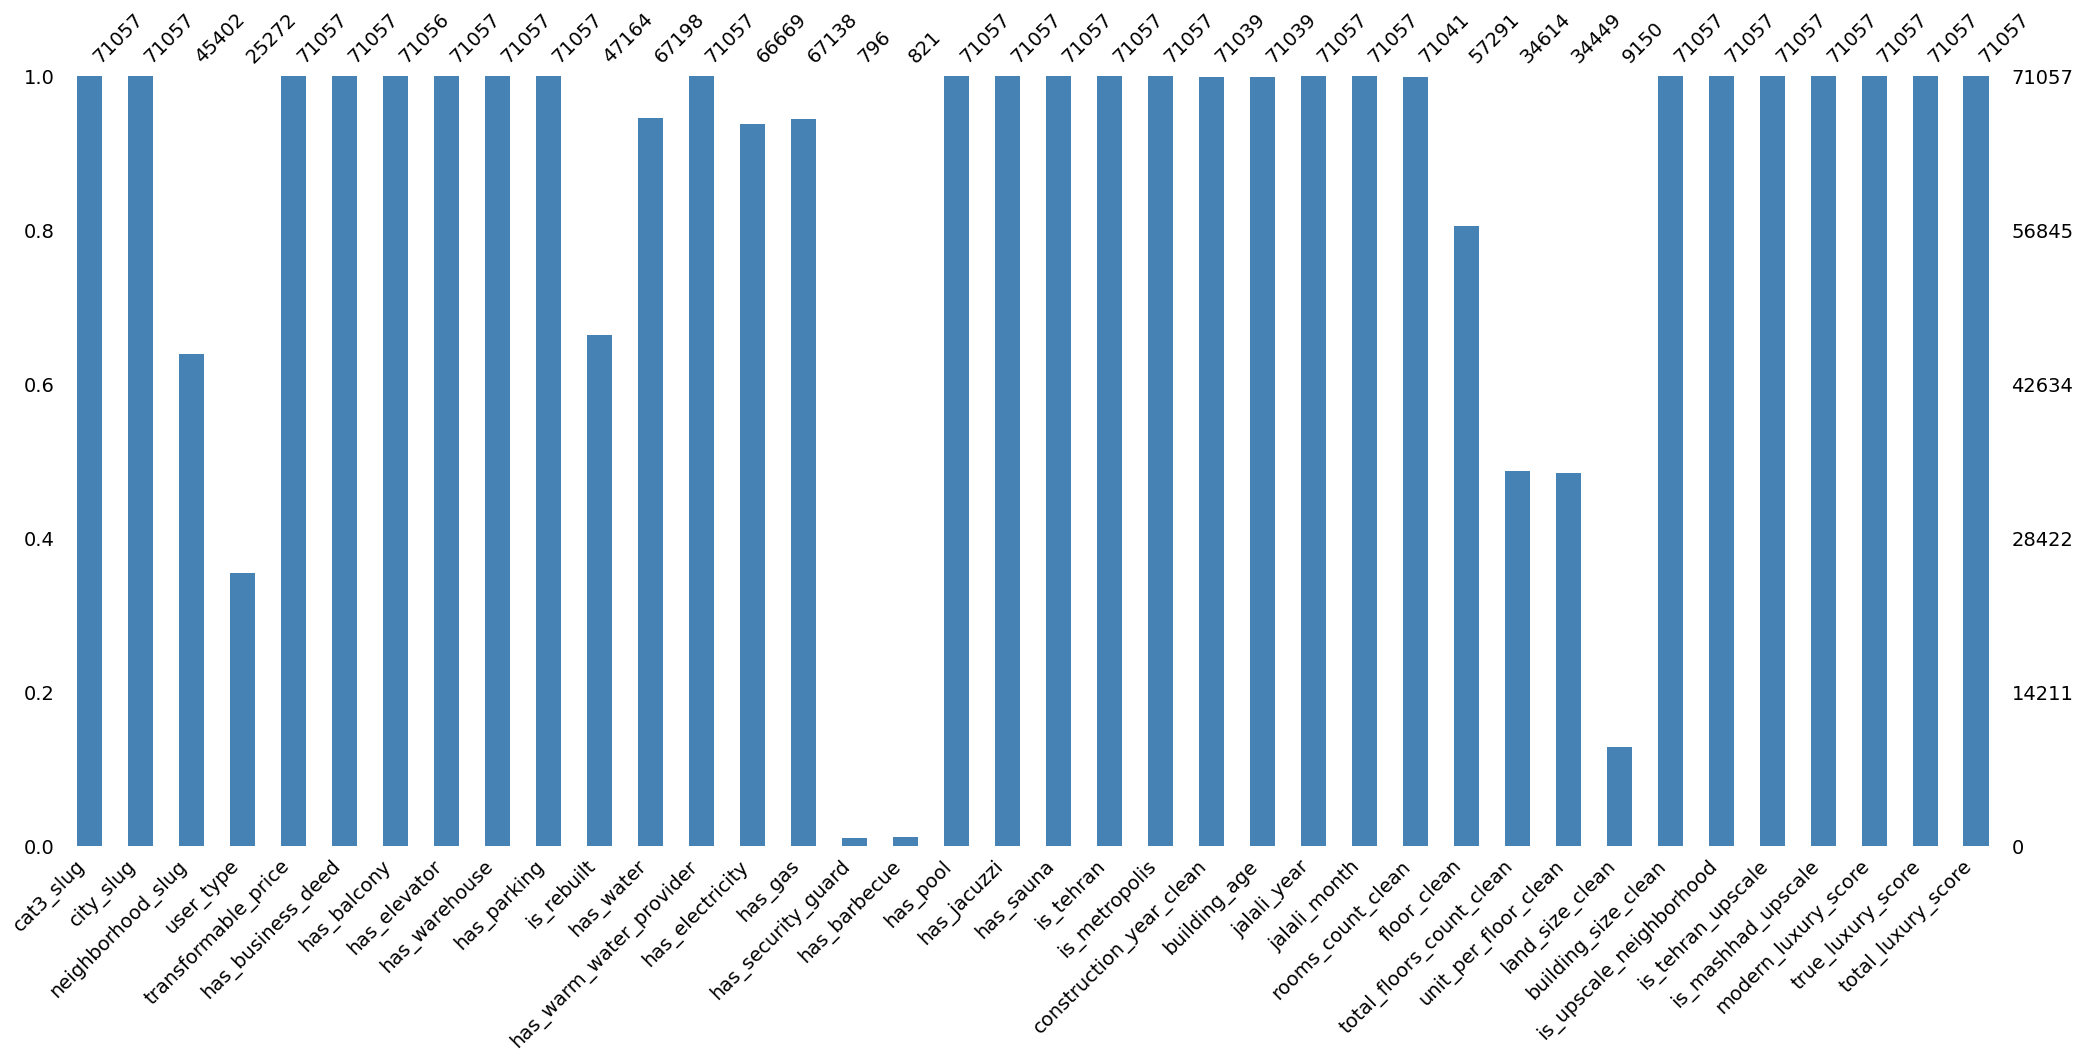

In [25]:
plt.figure(figsize=(18, 16))
msno.bar(rent_df, fontsize=14, color='steelblue')
plt.show()

In [26]:
rent_df.columns

Index(['cat3_slug', 'city_slug', 'neighborhood_slug', 'user_type',
       'transformable_price', 'has_business_deed', 'has_balcony',
       'has_elevator', 'has_warehouse', 'has_parking', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_security_guard', 'has_barbecue', 'has_pool', 'has_jacuzzi',
       'has_sauna', 'is_tehran', 'is_metropolis', 'construction_year_clean',
       'building_age', 'jalali_year', 'jalali_month', 'rooms_count_clean',
       'floor_clean', 'total_floors_count_clean', 'unit_per_floor_clean',
       'land_size_clean', 'building_size_clean', 'is_upscale_neighborhood',
       'is_tehran_upscale', 'is_mashhad_upscale', 'modern_luxury_score',
       'true_luxury_score', 'total_luxury_score'],
      dtype='object')

In [27]:
rent_df.iloc[:, :20].info()

<class 'pandas.core.frame.DataFrame'>
Index: 71057 entries, 5 to 999999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cat3_slug                71057 non-null  object 
 1   city_slug                71057 non-null  object 
 2   neighborhood_slug        45402 non-null  object 
 3   user_type                25272 non-null  object 
 4   transformable_price      71057 non-null  float64
 5   has_business_deed        71057 non-null  boolean
 6   has_balcony              71056 non-null  boolean
 7   has_elevator             71057 non-null  boolean
 8   has_warehouse            71057 non-null  boolean
 9   has_parking              71057 non-null  boolean
 10  is_rebuilt               47164 non-null  boolean
 11  has_water                67198 non-null  boolean
 12  has_warm_water_provider  71057 non-null  boolean
 13  has_electricity          66669 non-null  boolean
 14  has_gas                  6

In [28]:
rent_df.iloc[:, 20:].info()

<class 'pandas.core.frame.DataFrame'>
Index: 71057 entries, 5 to 999999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   is_tehran                 71057 non-null  int64  
 1   is_metropolis             71057 non-null  int64  
 2   construction_year_clean   71039 non-null  float64
 3   building_age              71039 non-null  float64
 4   jalali_year               71057 non-null  int64  
 5   jalali_month              71057 non-null  int64  
 6   rooms_count_clean         71041 non-null  float64
 7   floor_clean               57291 non-null  float64
 8   total_floors_count_clean  34614 non-null  float64
 9   unit_per_floor_clean      34449 non-null  float64
 10  land_size_clean           9150 non-null   float64
 11  building_size_clean       71057 non-null  float64
 12  is_upscale_neighborhood   71057 non-null  int64  
 13  is_tehran_upscale         71057 non-null  int64  
 14  is_mashhad

<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;"> تعریف Target و Featureها</h3>
<p style="direction: rtl; text-align: right;">در این مرحله <span dir="ltr">transformable_price</span> به‌عنوان متغیر هدف انتخاب می‌شود. برای کاهش اثر چولگی شدید قیمت، مدل روی <span dir="ltr">log1p(Target)</span> آموزش می‌بیند و در زمان ارزیابی دوباره به مقیاس واقعی برگردانده می‌شود.</p>
</div>


In [29]:
# تبدیل لگاریتمی قیمت هدف برای پایداری بیشتر
y = np.log1p(rent_df['transformable_price'])

# حذف ستون قیمت از ویژگی‌ها
X = rent_df.drop(columns=['transformable_price'], errors='ignore').copy()

bool_feature_cols = [c for c in X.columns if str(c).startswith('has_')]
for col in bool_feature_cols:
    X[col] = X[col].astype('float32')

categorical_cols = [
    'city_slug',
    'neighborhood_slug',
    'cat3_slug',
    'user_type'
]
categorical_cols = [c for c in categorical_cols if c in X.columns]

for col in categorical_cols:
    X[col] = X[col].astype('category')

print("Categorical features:", categorical_cols)
print("Feature count:", X.shape[1])

Categorical features: ['city_slug', 'neighborhood_slug', 'cat3_slug', 'user_type']
Feature count: 37


<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">تقسیم داده به Train، Validation و Test</h3>
<p style="direction: rtl; text-align: right;">داده‌ها به نسبت <span dir="ltr">70% / 15% / 15%</span> تقسیم می‌شوند. مجموعه <span dir="ltr">Test</span> تا پایان دست‌نخورده می‌ماند تا ارزیابی نهایی، تصویری منصفانه‌تر از عملکرد مدل روی داده‌های دیده‌نشده ارائه کند.</p>
</div>


In [30]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}\n")

Training set shape: (49739, 37)
Validation set shape: (10659, 37)
Test set shape: (10659, 37)



<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">آموزش مدل پایه (Baseline)</h3>
<p style="direction: rtl; text-align: right;">ابتدا یک مدل پایه با تنظیمات نزدیک به مدل قبلی آموزش می‌دهیم. این مدل معیار مقایسه است؛ بنابراین بعد از <span dir="ltr">Grid Search</span> می‌توانیم بررسی کنیم که بهینه‌سازی پارامترها واقعاً چه تغییری ایجاد کرده است.</p>
</div>


In [31]:
baseline_params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 128,
    'learning_rate': 0.03,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_data_in_leaf': 20,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_cols)
val_data = lgb.Dataset(
    X_val, label=y_val, reference=train_data, categorical_feature=categorical_cols
)

print("Training baseline LightGBM...")
baseline_model = lgb.train(
    baseline_params,
    train_data,
    num_boost_round=3000,
    valid_sets=[train_data, val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=150, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

baseline_val_pred_log = baseline_model.predict(
    X_val, num_iteration=baseline_model.best_iteration
)
baseline_val_pred_real = np.expm1(baseline_val_pred_log)
baseline_val_true_real = np.expm1(y_val)
baseline_val_r2 = r2_score(baseline_val_true_real, baseline_val_pred_real)

print(f"Baseline Validation R²: {baseline_val_r2:.4f}")
print(f"Baseline Best Iteration: {baseline_model.best_iteration}")

Training baseline LightGBM...
[100]	training's l1: 0.197944	valid_1's l1: 0.209763
[200]	training's l1: 0.174098	valid_1's l1: 0.194788
[300]	training's l1: 0.165004	valid_1's l1: 0.192621
[400]	training's l1: 0.158113	valid_1's l1: 0.191556
[500]	training's l1: 0.152442	valid_1's l1: 0.191115
[600]	training's l1: 0.147354	valid_1's l1: 0.19064
[700]	training's l1: 0.142729	valid_1's l1: 0.1907
[800]	training's l1: 0.138594	valid_1's l1: 0.190397
[900]	training's l1: 0.134743	valid_1's l1: 0.190346
[1000]	training's l1: 0.13114	valid_1's l1: 0.190386
Baseline Validation R²: 0.8638
Baseline Best Iteration: 878


<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">جست‌وجوی شبکه‌ای پارامترها (Grid Search)</h3>
<p style="direction: rtl; text-align: right;">در این مرحله چند مقدار برای پارامترهای مهم <span dir="ltr">LightGBM</span> امتحان می‌شود. معیار انتخاب در <span dir="ltr">Cross-Validation</span>، مقدار <span dir="ltr">R²</span> روی هدف لگاریتمی است. تعداد ترکیب‌ها عمداً محدود نگه داشته شده تا زمان اجرا عملی باقی بماند.</p>
</div>


In [32]:
grid_model = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',
    n_estimators=1200,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

param_grid = {
    'num_leaves': [31, 63, 127],
    'learning_rate': [0.02, 0.05],
    'min_child_samples': [10, 20, 40],
    'max_depth': [-1, 10]
}

print("\nStarting Grid Search...")
print("Total parameter combinations:", np.prod([len(v) for v in param_grid.values()]))

grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train, categorical_feature=categorical_cols)

print("\nBest Grid Search parameters:")
print(grid_search.best_params_)
print(f"Best CV R² (log scale): {grid_search.best_score_:.4f}")

# جدول تمام ترکیب‌ها برای بررسی آموزشی
grid_results = pd.DataFrame(grid_search.cv_results_).sort_values(
    'rank_test_score'
)
print("\nTop 10 Grid Search combinations:")
print(
    grid_results[[
        'rank_test_score', 'mean_test_score', 'std_test_score',
        'mean_train_score', 'params'
    ]].head(10).to_string(index=False)
)


Starting Grid Search...
Total parameter combinations: 36
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best Grid Search parameters:
{'learning_rate': 0.02, 'max_depth': -1, 'min_child_samples': 10, 'num_leaves': 127}
Best CV R² (log scale): 0.8919

Top 10 Grid Search combinations:
 rank_test_score  mean_test_score  std_test_score  mean_train_score                                                                               params
               1         0.891893        0.002391          0.964598 {'learning_rate': 0.02, 'max_depth': -1, 'min_child_samples': 10, 'num_leaves': 127}
               2         0.891798        0.001967          0.947658  {'learning_rate': 0.02, 'max_depth': -1, 'min_child_samples': 10, 'num_leaves': 63}
               3         0.891767        0.002220          0.959473 {'learning_rate': 0.02, 'max_depth': 10, 'min_child_samples': 10, 'num_leaves': 127}
               4         0.891637        0.001874          0.945454  {'learning_rate': 0

<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">آموزش مدل نهایی با بهترین پارامترها</h3>
<p style="direction: rtl; text-align: right;">بهترین ترکیب پیدا‌شده از <span dir="ltr">Grid Search</span> را به مدل نهایی منتقل می‌کنیم و با مجموعه <span dir="ltr">Validation</span> از <span dir="ltr">Early Stopping</span> استفاده می‌کنیم تا تعداد درخت‌ها بیش از نیاز افزایش پیدا نکند.</p>
</div>


In [33]:
best_params = grid_search.best_params_.copy()

final_params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': best_params['num_leaves'],
    'learning_rate': best_params['learning_rate'],
    'min_data_in_leaf': best_params['min_child_samples'],
    'max_depth': best_params['max_depth'],
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

print("\nFinal LightGBM parameters:")
print(final_params)

final_train_data = lgb.Dataset(
    X_train, label=y_train, categorical_feature=categorical_cols
)
final_val_data = lgb.Dataset(
    X_val, label=y_val, reference=final_train_data,
    categorical_feature=categorical_cols
)

print("\nTraining final LightGBM Model...")
model = lgb.train(
    final_params,
    final_train_data,
    num_boost_round=4000,
    valid_sets=[final_train_data, final_val_data],
    callbacks=[
        lgb.early_stopping(stopping_rounds=200, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)
print(f"\nBest Iteration: {model.best_iteration}")


Final LightGBM parameters:
{'objective': 'regression', 'metric': 'mae', 'boosting_type': 'gbdt', 'num_leaves': 127, 'learning_rate': 0.02, 'min_data_in_leaf': 10, 'max_depth': -1, 'feature_fraction': 0.85, 'bagging_fraction': 0.85, 'bagging_freq': 5, 'lambda_l1': 0.1, 'lambda_l2': 0.1, 'verbose': -1, 'random_state': 42, 'n_jobs': -1}

Training final LightGBM Model...
[100]	training's l1: 0.22713	valid_1's l1: 0.234727
[200]	training's l1: 0.181958	valid_1's l1: 0.198893
[300]	training's l1: 0.170497	valid_1's l1: 0.19371
[400]	training's l1: 0.16373	valid_1's l1: 0.192436
[500]	training's l1: 0.158492	valid_1's l1: 0.191802
[600]	training's l1: 0.153912	valid_1's l1: 0.191209
[700]	training's l1: 0.149882	valid_1's l1: 0.190881
[800]	training's l1: 0.146191	valid_1's l1: 0.190551
[900]	training's l1: 0.142797	valid_1's l1: 0.19038
[1000]	training's l1: 0.139503	valid_1's l1: 0.190157
[1100]	training's l1: 0.136364	valid_1's l1: 0.190012
[1200]	training's l1: 0.133433	valid_1's l1: 0.1

<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">ارزیابی مدل روی Validation و Test</h3>
<p style="direction: rtl; text-align: right;">پیش‌بینی‌ها ابتدا از مقیاس لگاریتمی به قیمت واقعی برگردانده می‌شوند. سپس معیارهای <span dir="ltr">MAE</span>، <span dir="ltr">RMSE</span>، <span dir="ltr">R²</span>، <span dir="ltr">MAPE</span> و <span dir="ltr">Median Absolute Error</span> محاسبه می‌شوند تا عملکرد مدل از چند زاویه بررسی شود.</p>
</div>


In [34]:
def evaluate_predictions(model, X_part, y_part, name):
    pred_log = model.predict(X_part, num_iteration=model.best_iteration)
    pred_real = np.expm1(pred_log)
    true_real = np.expm1(y_part)

    mae = mean_absolute_error(true_real, pred_real)
    rmse = np.sqrt(mean_squared_error(true_real, pred_real))
    r2 = r2_score(true_real, pred_real)
    mape = mean_absolute_percentage_error(true_real, pred_real) * 100
    medae = median_absolute_error(true_real, pred_real)

    print(f"\n--- {name} Metrics ---")
    print(f"MAE      : {mae:,.0f} Toman")
    print(f"RMSE     : {rmse:,.0f} Toman")
    print(f"R²       : {r2:.4f} ({r2*100:.2f}%)")
    print(f"MAPE     : {mape:.2f}%")
    print(f"Median AE: {medae:,.0f} Toman")

    return pred_log, pred_real, true_real, {
        'MAE': mae, 'RMSE': rmse, 'R2': r2,
        'MAPE': mape, 'MedianAE': medae
    }

val_pred_log, val_pred_real, val_true_real, val_metrics = evaluate_predictions(
    model, X_val, y_val, 'Validation'
)
test_pred_log, test_pred_real, test_true_real, test_metrics = evaluate_predictions(
    model, X_test, y_test, 'Test'
)


--- Validation Metrics ---
MAE      : 235,117,330 Toman
RMSE     : 630,822,355 Toman
R²       : 0.8614 (86.14%)
MAPE     : 20.43%
Median AE: 90,306,187 Toman

--- Test Metrics ---
MAE      : 242,711,283 Toman
RMSE     : 700,621,553 Toman
R²       : 0.8580 (85.80%)
MAPE     : 20.14%
Median AE: 92,144,957 Toman


<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">مقایسه Baseline با مدل Grid Search</h3>
<p style="direction: rtl; text-align: right;">نتایج مدل پایه و مدل بهینه‌شده کنار هم قرار می‌گیرند. این مقایسه کمک می‌کند اثر واقعی مرحله بهینه‌سازی را جدا از سایر تغییرات مشاهده کنیم.</p>
</div>


In [35]:
comparison = pd.DataFrame({
    'Model': ['Baseline', 'Grid Search'],
    'Validation_R2': [baseline_val_r2, val_metrics['R2']],
    'Validation_R2_percent': [baseline_val_r2 * 100, val_metrics['R2'] * 100],
    'Test_R2': [np.nan, test_metrics['R2']],
    'Test_R2_percent': [np.nan, test_metrics['R2'] * 100]
})

print("\n--- Model Comparison ---")
print(comparison.to_string(index=False))


--- Model Comparison ---
      Model  Validation_R2  Validation_R2_percent  Test_R2  Test_R2_percent
   Baseline       0.863841              86.384071      NaN              NaN
Grid Search       0.861372              86.137160 0.858014        85.801365


<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">ساخت جدول نتایج پیش‌بینی</h3>
<p style="direction: rtl; text-align: right;">برای هر رکورد، قیمت واقعی، قیمت پیش‌بینی‌شده، مقدار خطا و درصد خطا ذخیره می‌شود. این جدول پایه تحلیل‌های بعدی مانند بررسی نمونه‌های ناموفق و شناسایی الگوهای خطاست.</p>
</div>


In [36]:
val_results = X_val.copy()
val_results['actual_price'] = val_true_real
val_results['predicted_price'] = val_pred_real
val_results['residual'] = val_results['actual_price'] - val_results['predicted_price']
val_results['abs_error'] = val_results['residual'].abs()
val_results['pct_error'] = (
    val_results['abs_error'] / val_results['actual_price'].replace(0, np.nan)
) * 100
val_results['log_actual'] = y_val
val_results['log_pred'] = val_pred_log
val_results['log_residual'] = val_results['log_actual'] - val_results['log_pred']

test_results = X_test.copy()
test_results['actual_price'] = test_true_real
test_results['predicted_price'] = test_pred_real
test_results['residual'] = test_results['actual_price'] - test_results['predicted_price']
test_results['abs_error'] = test_results['residual'].abs()
test_results['pct_error'] = (
    test_results['abs_error'] / test_results['actual_price'].replace(0, np.nan)
) * 100
test_results['log_actual'] = y_test
test_results['log_pred'] = test_pred_log
test_results['log_residual'] = test_results['log_actual'] - test_results['log_pred']

<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">مشاهده نمونه‌ای از پیش‌بینی‌ها</h3>
<p style="direction: rtl; text-align: right;">در این بخش چند ردیف از نتایج <span dir="ltr">Validation</span> و <span dir="ltr">Test</span> نمایش داده می‌شود تا خروجی مدل در سطح رکورد قابل مشاهده و بررسی باشد.</p>
</div>


In [37]:
print("\n--- نمونه Validation ---")
print(val_results[['actual_price', 'predicted_price', 'residual', 'pct_error']].head(10).to_string())

print("\n--- نمونه Test ---")
print(test_results[['actual_price', 'predicted_price', 'residual', 'pct_error']].head(10).to_string())


--- نمونه Validation ---
        actual_price  predicted_price      residual  pct_error
828890  1.049960e+09     1.080132e+09 -3.017237e+07   2.873669
938333  2.266500e+09     3.204713e+09 -9.382131e+08  41.394796
869496  4.166500e+08     3.103834e+08  1.062666e+08  25.504993
496825  2.833100e+09     1.306796e+09  1.526304e+09  53.873994
336573  3.533330e+08     3.964872e+08 -4.315422e+07  12.213471
568950  6.333100e+08     5.610927e+08  7.221733e+07  11.403156
434236  4.666300e+08     4.723771e+08 -5.747124e+06   1.231623
267237  1.103333e+09     1.576758e+09 -4.734250e+08  42.908621
417465  4.800000e+08     4.902843e+08 -1.028426e+07   2.142554
400452  3.333300e+08     4.218020e+08 -8.847199e+07  26.541862

--- نمونه Test ---
        actual_price  predicted_price      residual  pct_error
640134  2.533330e+08     3.357334e+08 -8.240043e+07  32.526530
965632  1.566600e+09     1.473728e+09  9.287187e+07   5.928244
898814  6.999500e+08     4.905083e+08  2.094417e+08  29.922379
257324  1

<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">بررسی بزرگ‌ترین خطاها</h3>
<p style="direction: rtl; text-align: right;">بیست مورد با بیشترین خطای مطلق استخراج می‌شوند. این مرحله برای <span dir="ltr">Error Analysis</span> مهم است، زیرا ممکن است نشان دهد مدل در چه نوع املاک یا چه محدوده قیمتی عملکرد ضعیف‌تری دارد.</p>
</div>


In [38]:
print("\n--- 20 خطای بزرگ Validation ---")
print(val_results.nlargest(20, 'abs_error')[
    ['actual_price', 'predicted_price', 'abs_error', 'pct_error']].to_string())

print("\n--- 20 خطای بزرگ Test ---")
print(test_results.nlargest(20, 'abs_error')[['actual_price', 'predicted_price', 'abs_error', 'pct_error']].to_string())


--- 20 خطای بزرگ Validation ---
        actual_price  predicted_price     abs_error    pct_error
588058  2.066500e+10     6.669370e+09  1.399563e+10    67.726252
492298  2.399370e+10     1.153475e+10  1.245895e+10    51.925917
358533  1.600000e+10     2.725676e+10  1.125676e+10    70.354727
230117  3.000333e+10     1.922682e+10  1.077651e+10    35.917724
185325  6.499500e+09     1.715120e+10  1.065170e+10   163.884845
366696  2.999900e+09     1.338814e+10  1.038824e+10   346.286159
98453   2.533100e+10     1.529543e+10  1.003557e+10    39.617723
963184  1.200333e+10     3.729086e+09  8.274247e+09    68.932912
455213  9.999300e+09     1.959965e+09  8.039335e+09    80.398982
303122  1.733200e+10     9.380701e+09  7.951299e+09    45.876410
154844  1.249880e+10     4.630963e+09  7.867837e+09    62.948738
890401  1.500333e+10     7.172262e+09  7.831071e+09    52.195540
960851  1.716500e+08     7.939460e+09  7.767810e+09  4525.377295
311997  9.500000e+09     1.865585e+09  7.634415e+09    80

<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">اهمیت ویژگی‌ها</h3>
<p style="direction: rtl; text-align: right;">اهمیت ویژگی‌ها بر اساس <span dir="ltr">Gain</span> محاسبه می‌شود. این خروجی نشان می‌دهد کدام متغیرها بیشترین نقش را در کاهش خطای مدل داشته‌اند؛ البته اهمیت ویژگی با رابطه علّی یکسان نیست.</p>
</div>


In [39]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance (Gain)': model.feature_importance(importance_type='gain')
}).sort_values('Importance (Gain)', ascending=False)

print("\n--- Top 20 Most Important Features ---")
print(importance.head(20).to_string(index=False))


--- Top 20 Most Important Features ---
                 Feature  Importance (Gain)
       neighborhood_slug      244346.182747
     building_size_clean      240981.589388
               city_slug      177549.921732
       rooms_count_clean       31927.083917
      total_luxury_score       22432.570063
               is_tehran       21026.375670
 construction_year_clean       16448.109234
             floor_clean        8958.743905
               cat3_slug        8875.755019
     modern_luxury_score        7558.104517
         land_size_clean        7275.512174
            jalali_month        5326.013945
            has_elevator        4374.055918
             has_parking        4236.996950
              is_rebuilt        2768.111482
            building_age        2301.245521
total_floors_count_clean        2003.042104
    unit_per_floor_clean        1775.190460
               user_type        1747.020067
           is_metropolis        1284.852246


<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">نمودار Actual در برابر Predicted</h3>
<p style="direction: rtl; text-align: right;">در این نمودار قیمت واقعی با قیمت پیش‌بینی‌شده مقایسه می‌شود. نزدیک بودن نقاط به خط ایده‌آل نشان می‌دهد پیش‌بینی‌ها تا چه اندازه با مقادیر واقعی هم‌راستا هستند.</p>
</div>


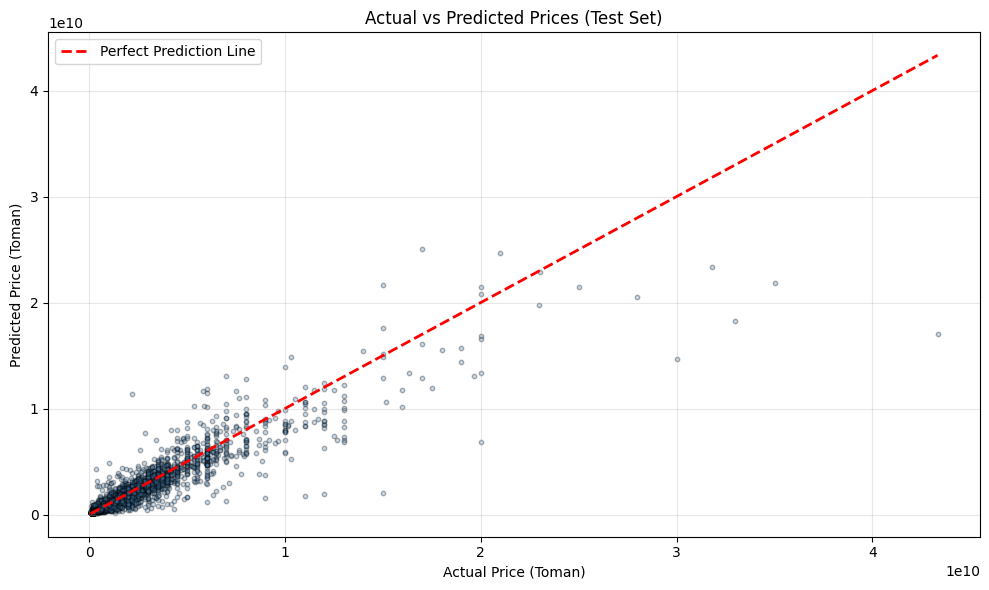

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(test_true_real, test_pred_real, alpha=0.3, color='steelblue', edgecolors='k', s=10)
plt.plot([test_true_real.min(), test_true_real.max()],
         [test_true_real.min(), test_true_real.max()],
         'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Price (Toman)')
plt.ylabel('Predicted Price (Toman)')
plt.title('Actual vs Predicted Prices (Test Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">نمودار Residual</h3>
<p style="direction: rtl; text-align: right;">باقیمانده یا <span dir="ltr">Residual</span> برابر اختلاف مقدار واقعی و پیش‌بینی‌شده است. این نمودار کمک می‌کند الگوهای سیستماتیک خطا، پراکندگی خطا و نواحی‌ای که مدل در آن‌ها دچار خطای بیشتری می‌شود بررسی شوند.</p>
</div>


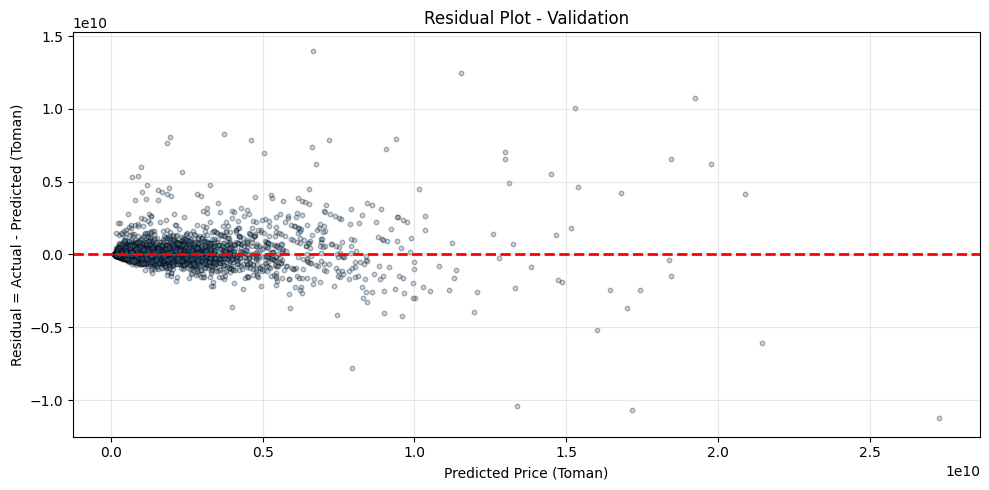

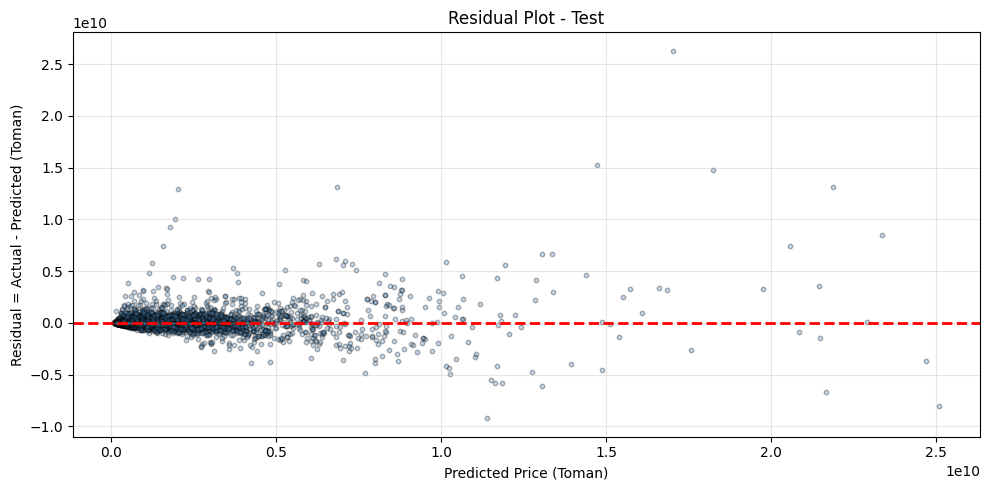

In [41]:
plt.figure(figsize=(10, 5))
plt.scatter(val_results['predicted_price'], val_results['residual'],
            alpha=0.3, color='steelblue', edgecolors='k', s=10)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Price (Toman)')
plt.ylabel('Residual = Actual - Predicted (Toman)')
plt.title('Residual Plot - Validation')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(test_results['predicted_price'], test_results['residual'],
            alpha=0.3, color='steelblue', edgecolors='k', s=10)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Price (Toman)')
plt.ylabel('Residual = Actual - Predicted (Toman)')
plt.title('Residual Plot - Test')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




<div dir="rtl" style="direction: rtl; text-align: right; line-height: 200%; font-family: Vazir, Tahoma, Arial, sans-serif; font-size: medium;">
<h3 style="direction: rtl; text-align: right; line-height: 200%;">توزیع درصد خطا</h3>
<p style="direction: rtl; text-align: right;">در پایان توزیع درصد خطا برای <span dir="ltr">Validation</span> و <span dir="ltr">Test</span> نمایش داده می‌شود تا شکل کلی خطاها و تفاوت رفتار دو مجموعه بهتر دیده شود.</p>
</div>


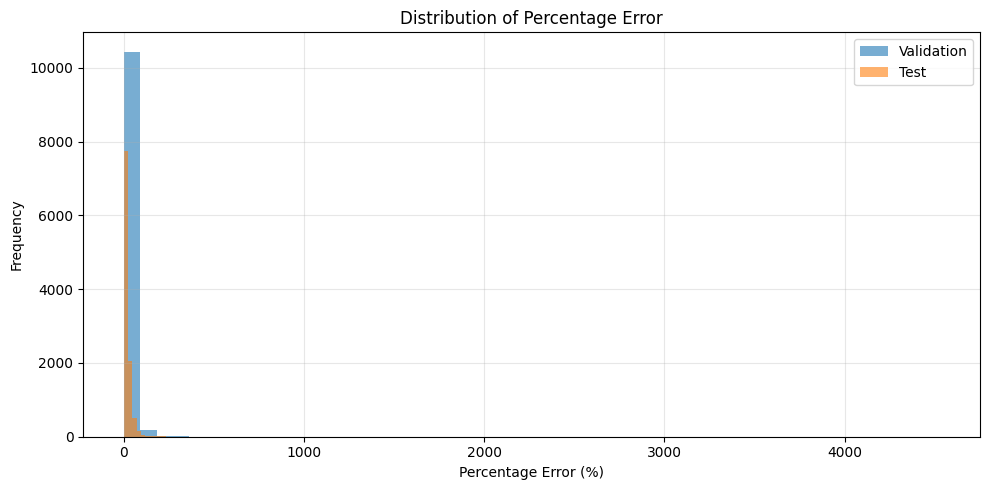

In [42]:
plt.figure(figsize=(10, 5))
plt.hist(val_results['pct_error'].dropna(), bins=50, alpha=0.6, label='Validation')
plt.hist(test_results['pct_error'].dropna(), bins=50, alpha=0.6, label='Test')
plt.xlabel('Percentage Error (%)')
plt.ylabel('Frequency')
plt.title('Distribution of Percentage Error')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
